In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [3]:
def step_mat(K,dt):
    if K<0:
        return np.array([[np.cosh(dt*np.sqrt(-K)),np.sqrt(-K)*np.sinh(dt*np.sqrt(-K))],[1/np.sqrt(-K)*np.sinh(dt*np.sqrt(-K)),np.cosh(dt*np.sqrt(-K))]])
    if K==0:
        return np.array([[1,0],[dt,1]])
    if K>0:
        return np.array([[np.cos(dt*np.sqrt(K)),-np.sqrt(K)*np.sin(dt*np.sqrt(K))],[1/np.sqrt(K)*np.sin(dt*np.sqrt(K)),np.cos(dt*np.sqrt(K))]])

def arg(z):
    ans = np.arctan2(z[1],z[0])
    if ans<0:
        return ans+2*np.pi
    else:
        return ans
    
def new_arg(old_arg, K, dt):
    old_z = [np.cos(old_arg), np.sin(old_arg)]
    new_z = old_z @ step_mat(K, dt)
    return arg(new_z)

def new_sost(DP, old_sost, K, dt):
    oarg = np.pi / DP * (1 + 2 * old_sost)
    narg = new_arg(oarg, K, dt)
    return int(np.floor(narg * DP / 2 / np.pi))

def myvstack(A, B):
    if A.shape[1] == B.shape[1]:
        return np.vstack((A, B))

In [49]:
def get_zerosdiff_modern(M, R, maxzerosnum, K_dist, update_dist):
    ZEROS_GLOB = np.zeros((R, maxzerosnum))
    ZEROSDIFF_GLOB = np.zeros((R, maxzerosnum))
    for r in tqdm(range(R), desc='Расчёт нулей'):
        if update_dist[0] == 'const':
            D = update_dist[1]
            x0s = np.arange(0, M, D)
            Ds = D * np.ones(len(x0s))
            if sum(Ds) > M:
                Ds[-1] -= sum(Ds) - M
        elif update_dist[0] == 'exp':
            ED = update_dist[1]
            x0s = []
            Ds = []
            summ = 0
            while summ < M:
                D = np.random.exponential(ED)
                x0s.append(summ)
                Ds.append(D)
                summ += D
            if sum(Ds) > M:
                Ds[-1] -= sum(Ds) - M
        Z_old = np.array([0.0, 1.0])
        ZEROS = []
        if K_dist[0] == 'U':
            Ks = np.random.uniform(K_dist[1], K_dist[2], size=len(x0s))
        elif K_dist[0] == 'N':
            Ks = np.random.normal(K_dist[1], K_dist[2], size=len(x0s))
        
        for i in range(len(x0s)):
            x0 = x0s[i]
            D_curr = Ds[i]
            K = Ks[i]
            #print(x0, D_curr, K)
            B = step_mat(K, D_curr)
            Z_new = Z_old @ B
            Z_new /= np.linalg.norm(Z_new)
            
            if K < 0 and (Z_old[0] == 0 or (Z_old[1] / Z_old[0])**2 + K > 0):
                shift = np.arctanh(-np.sqrt(-K) * Z_old[0] / Z_old[1]) / np.sqrt(-K)
                if shift > 0 and shift < D_curr:
                    ZEROS.append(x0 + shift)
            elif K == 0 and Z_old[0] * Z_old[1] < 0:
                shift = -Z_old[0] / Z_old[1]
                if shift < D_curr:
                    ZEROS.append(x0 + shift)
            elif K > 0:
                if Z_old[0] * Z_old[1] < 0:
                    shift = -np.arctan(Z_old[0] / Z_old[1] * np.sqrt(K)) / np.sqrt(K)
                else:
                    shift = (np.pi - np.arctan(Z_old[0] / Z_old[1] * np.sqrt(K))) / np.sqrt(K)
                while shift < D_curr:
                    ZEROS.append(x0 + shift)
                    shift += np.pi / np.sqrt(K)
            
            Z_old = np.array(Z_new)
            x0 += D
        #print(f'{len(ZEROS)} zeros')
        if len(ZEROS) > 0:
            ZEROS_GLOB[r, 0] = ZEROS[0]
            ZEROSDIFF_GLOB[r, 0] = ZEROS[0]
            for j in range(1, len(ZEROS)):
                ZEROS_GLOB[r, j] = ZEROS[j]
                ZEROSDIFF_GLOB[r, j] = ZEROS[j] - ZEROS[j - 1]
    #np.save(f'zerosdiff_{}_K_U({Kmin}_{Kmax})_M{M}_D{D}_R{R}', ZEROSDIFF_GLOB)
    np.save(f'zerosdiff_K_{K_dist[0]}({K_dist[1]}_{K_dist[2]})_M{M}_D{update_dist[0]}{update_dist[1]}_R{R}', ZEROSDIFF_GLOB)
    return ZEROSDIFF_GLOB

In [60]:
#np.random.seed(42)
#ZDE = get_zerosdiff_equiv(-1, 1, 200, 1000, 100, 1, 100)

In [125]:
np.random.seed(42)
ZDEM = get_zerosdiff_modern(5000, 5000, 70, ('U', -0.02, 0.02), ('const', 1))
print((ZDEM>1e-6).sum())

Расчёт нулей: 100%|██████████| 5000/5000 [35:25<00:00,  2.35it/s]

200929


In [117]:
arr = np.load('zerosdiff_equiv_K_U(-0.02_0.02)_M5000_D1_R2500.npy')

In [119]:
arr.shape

(2500, 70)

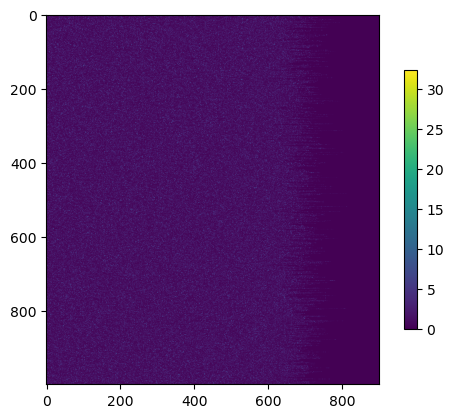

In [115]:
plt.imshow(ZDEM)
plt.colorbar(shrink=0.7)
plt.show()

## Старые функции

In [ ]:
def get_zerosdiff_equiv(Kmin, Kmax, maxzerosnum, M, N, D, R):
    MN = M * N
    ZEROS_GLOB = np.zeros((R, maxzerosnum))
    ZEROSDIFF_GLOB = np.zeros((R, maxzerosnum))
    for r in tqdm(range(R), desc='Расчёт решений'):
        Z_old = np.array([0.0, 1.0])
        Z_new = np.array([0.0, 0.0])
        ZEROS = []
        for i in range(MN):
            if i % (D * N) == 0: # в точках обновления вычисляем новое значение K и переходную матрицу
                K = np.random.uniform(Kmin, Kmax)
                # K = np.random.normal(Kmin, Kmax)
                B = step_mat(K, 1/N)
                # print(K)
            Z_new = Z_old @ B # делаем шаг
            Z_new /= np.linalg.norm(Z_new) # нормируем вектор z
            if Z_new[0] * Z_old[0] < 0: # отлавливаем нули
                ZEROS.append((i + 0.5) / N)
            Z_old[0] = Z_new[0]
            Z_old[1] = Z_new[1]
        #print(ZEROS)
        if len(ZEROS) > 0:
            ZEROS_GLOB[r, 0] = ZEROS[0]
            ZEROSDIFF_GLOB[r, 0] = ZEROS[0]
            for j in range(1, len(ZEROS)):
                ZEROS_GLOB[r, j] = ZEROS[j]
                ZEROSDIFF_GLOB[r, j] = ZEROS[j] - ZEROS[j - 1]
        #print(len(ZEROS), 'zeros')
        #print(ZEROSDIFF_GLOB)
    return ZEROSDIFF_GLOB
    #np.save(f'zerosdiff_equiv_K_N({Kmin}_{Kmax})_M{M}_N{N}_D{D}_R{R}', ZEROSDIFF_GLOB)

In [31]:
def get_zerosdiff_pois(Kmin, Kmax, maxzerosnum, M, N, D, R):
    lamb = N * D #матожидание длины отрезка обновления
    ZEROS_GLOB = np.zeros((R,maxzerosnum))
    ZEROSDIFF_GLOB = np.zeros((R,maxzerosnum))
    for r in tqdm(range(R), desc='Расчёт решений'):
        Z_old = np.array([0.0,1.0])
        Z_new = np.array([0.0,0.0])
        ZEROS = []
        summ = 0
        while summ < M*N:
            length = round(np.random.exponential(lamb))
            if summ + length >= M*N:
                length -= (summ + length - M*N)
            #print('length =', length)
            K = np.random.uniform(Kmin, Kmax)
            # K = np.random.normal(0, 1 / np.sqrt(3))
            B = step_mat(K, 1/N)
            for i in range(summ, summ + length):
                Z_new = Z_old @ B
                Z_new /= np.linalg.norm(Z_new)
                if Z_new[0] * Z_old[0] < 0:
                    ZEROS.append((i-0.5)/N)
                Z_old[0] = Z_new[0]
                Z_old[1] = Z_new[1]
            summ += length
        ZEROS_GLOB[r,0] = ZEROS[0]
        ZEROSDIFF_GLOB[r,0] = ZEROS[0]
        for j in range(1,len(ZEROS)):
            ZEROS_GLOB[r,j] = ZEROS[j]
            ZEROSDIFF_GLOB[r,j] = ZEROS[j] - ZEROS[j - 1]
        # print(len(ZEROS), 'zeros')
            
    np.save(f'zerosdiff_pois_K_U({Kmin}_{Kmax})_M{M}_N{N}_D{D}_R{R}',ZEROSDIFF_GLOB)

In [33]:
get_zerosdiff_pois(-1, 1, 100, 150, 100, 1, 10000)
get_zerosdiff_pois(-3, 3, 100, 150, 100, 1, 10000)
get_zerosdiff_pois(-10, 10, 100, 150, 100, 1, 10000)

Расчёт решений: 100%|██████████| 10000/10000 [1:03:09<00:00,  2.64it/s]


In [21]:
1 / np.sqrt(3)

0.5773502691896258